# Semana 2 — Estadística descriptiva e inferencial

**Alumno:** bambam2907 · **Optativa 3 — Ciencia de Datos**

Se reutiliza `spotify_200.csv` (200 canciones, muestra del Spotify Tracks Dataset de Kaggle) y la misma
variable numérica de la Semana 1: `popularity` (0-100). Se calculan sus descriptivos, se compara su histograma
con una curva normal, se simulan una binomial y una Poisson con `scipy.stats` y se implementa un mini
clasificador de spam con el teorema de Bayes.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")

df = pd.read_csv("spotify_200.csv")
col = df.select_dtypes("number").columns[0]
datos = df[col].dropna()
print("Variable:", col, "| n =", len(datos))

Variable: popularity | n = 200


## 1) Estadística descriptiva

Media:      34.585
Mediana:    36.500
Moda:       0 (aparece 21 veces)
Desv. est.: 22.898
Asimetria:  0.045
Curtosis:   -0.982


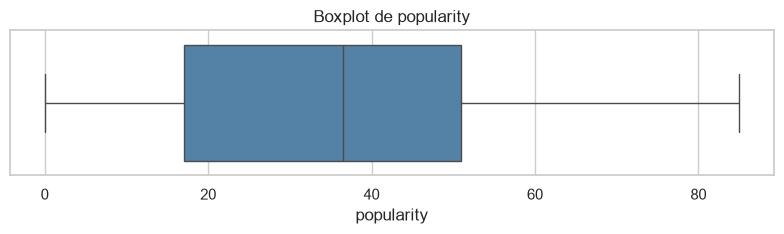

In [2]:
# Medidas de tendencia central y dispersion
media = datos.mean()
mediana = datos.median()
moda = datos.mode()[0]
std = datos.std()

print(f"Media:      {media:.3f}")
print(f"Mediana:    {mediana:.3f}")
print(f"Moda:       {moda} (aparece {int((datos == moda).sum())} veces)")
print(f"Desv. est.: {std:.3f}")
print(f"Asimetria:  {stats.skew(datos):.3f}")
print(f"Curtosis:   {stats.kurtosis(datos):.3f}")

# Boxplot rapido para ver dispersion y valores extremos
plt.figure(figsize=(8, 2.5))
sns.boxplot(x=datos, color="steelblue")
plt.title(f"Boxplot de {col}")
plt.tight_layout()
plt.show()

**Interpretación.** La media (34.6) y la mediana (36.5) están muy cerca y la asimetría es casi cero (0.04),
así que la distribución es prácticamente simétrica. Sin embargo la moda es 0: hay 21 canciones con popularidad 0,
un pico que no encaja con el resto de los valores. La desviación estándar de 22.9 es grande respecto a la media
(los datos se reparten por casi todo el rango 0-100) y la curtosis negativa (-0.98) indica una forma más plana
que la campana normal. El boxplot lo resume: la caja (rango intercuartil) es ancha y no marca valores atípicos.

## 2) Histograma vs. curva normal teórica

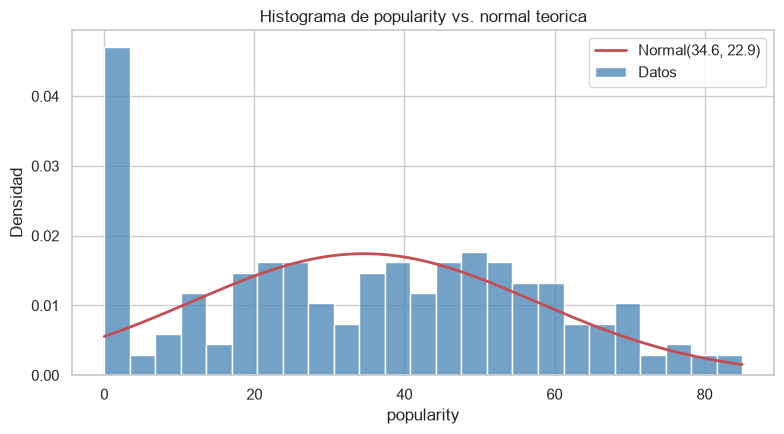

Shapiro-Wilk: W = 0.959, p = 1.48e-05


In [3]:
# Histograma en densidad con la normal teorica encima
x = np.linspace(datos.min(), datos.max(), 200)

plt.figure(figsize=(8, 4.5))
sns.histplot(datos, bins=25, stat="density", color="steelblue", label="Datos")
plt.plot(x, stats.norm.pdf(x, media, std), "r-", lw=2, label=f"Normal({media:.1f}, {std:.1f})")
plt.title(f"Histograma de {col} vs. normal teorica")
plt.xlabel(col); plt.ylabel("Densidad")
plt.legend()
plt.tight_layout()
plt.show()

# Prueba de normalidad
w, p_valor = stats.shapiro(datos)
print(f"Shapiro-Wilk: W = {w:.3f}, p = {p_valor:.2e}")

**Interpretación. ¿La variable se parece a una normal?** Solo a medias. A favor: es simétrica (media ≈ mediana,
asimetría ≈ 0) y el centro de la campana coincide con el centro de los datos. En contra: el histograma es más plano y
ancho que la curva roja (curtosis -0.98), tiene un pico en 0 que la normal no explica y la variable está acotada en 0-100.
La prueba de Shapiro-Wilk lo confirma: W = 0.959 con p ≈ 1.5e-05, muy por debajo de 0.05, por lo que se rechaza la
normalidad. Conclusión: `popularity` no sigue una distribución normal, aunque sea simétrica.

## 3) Distribuciones teóricas con `scipy.stats`

p = P(explicita) = 0.100
E[X] = n*p = 1.00 | media simulada = 0.971
P(X = 0) = 0.349 | P(X >= 3) = 0.070


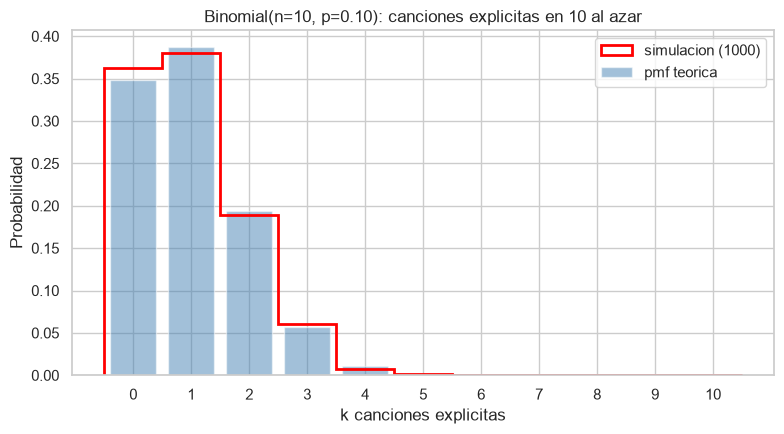

In [4]:
# (a) Binomial: de n=10 canciones al azar, cuantas son explicitas
n = 10
p = df["explicit"].mean()
k = np.arange(0, n + 1)
pmf_binom = stats.binom.pmf(k, n, p)
sim_binom = stats.binom.rvs(n, p, size=1000, random_state=42)

print(f"p = P(explicita) = {p:.3f}")
print(f"E[X] = n*p = {n * p:.2f} | media simulada = {sim_binom.mean():.3f}")
print(f"P(X = 0) = {pmf_binom[0]:.3f} | P(X >= 3) = {stats.binom.sf(2, n, p):.3f}")

plt.figure(figsize=(8, 4.5))
plt.bar(k, pmf_binom, alpha=0.5, color="steelblue", label="pmf teorica")
plt.hist(sim_binom, bins=np.arange(-0.5, n + 1.5, 1), density=True,
         histtype="step", lw=2, color="red", label="simulacion (1000)")
plt.title(f"Binomial(n={n}, p={p:.2f}): canciones explicitas en 10 al azar")
plt.xlabel("k canciones explicitas"); plt.ylabel("Probabilidad")
plt.xticks(k); plt.legend()
plt.tight_layout()
plt.show()

**Interpretación.** La binomial modela cuántos "éxitos" (canciones explícitas) hay en n = 10 ensayos independientes
con la misma probabilidad p = 0.10 (proporción real del dataset: 20 de 200). El valor esperado es E[X] = 1, es decir,
en promedio una canción explícita por cada 10; la simulación da 0.971, muy cerca. Como p es pequeña la forma es asimétrica
a la derecha: lo más probable es 0 o 1 (P(X=0) = 0.349) y sacar 3 o más es raro (0.070). Las barras de la pmf y el
contorno de la simulación casi coinciden, como se espera con 1000 repeticiones.

lambda = 4 | media simulada = 3.923
P(X = 4) = 0.195
P(X > 7)  = 0.051


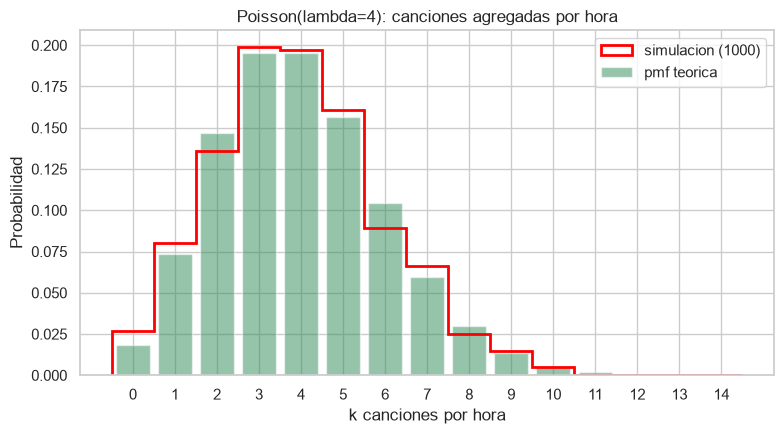

In [5]:
# (b) Poisson: canciones agregadas a una playlist por hora, promedio lam=4
lam = 4
k = np.arange(0, 15)
pmf_pois = stats.poisson.pmf(k, lam)
sim_pois = stats.poisson.rvs(lam, size=1000, random_state=42)

print(f"lambda = {lam} | media simulada = {sim_pois.mean():.3f}")
print(f"P(X = {lam}) = {stats.poisson.pmf(lam, lam):.3f}")
print(f"P(X > 7)  = {stats.poisson.sf(7, lam):.3f}")

plt.figure(figsize=(8, 4.5))
plt.bar(k, pmf_pois, alpha=0.5, color="seagreen", label="pmf teorica")
plt.hist(sim_pois, bins=np.arange(-0.5, 15.5, 1), density=True,
         histtype="step", lw=2, color="red", label="simulacion (1000)")
plt.title(f"Poisson(lambda={lam}): canciones agregadas por hora")
plt.xlabel("k canciones por hora"); plt.ylabel("Probabilidad")
plt.xticks(k); plt.legend()
plt.tight_layout()
plt.show()

**Interpretación.** La Poisson modela conteos de eventos en un intervalo fijo cuando ocurren a una tasa constante,
aquí λ = 4 canciones agregadas por hora. La media y la varianza valen λ, y la simulación da una media de 3.923, cercana a 4.
El valor más probable está alrededor de λ (P(X=4) = 0.195), con una cola a la derecha: más de 7 canciones en una hora
ocurre solo el 5.1% de las veces. De nuevo la simulación reproduce la pmf teórica; a diferencia de la binomial, aquí no
hay un máximo de ensayos, solo una tasa.

## 4) Mini clasificador de spam con Bayes

In [6]:
# Calculo base: P(spam | contiene 'gratis')
p_spam = 0.4
p_no_spam = 1 - p_spam
p_gratis_dado_spam = 0.8
p_gratis_dado_no = 0.1

p_gratis = p_gratis_dado_spam * p_spam + p_gratis_dado_no * p_no_spam
p_spam_dado_gratis = p_gratis_dado_spam * p_spam / p_gratis

print(f"P(gratis)        = {p_gratis:.3f}")
print(f"P(spam | gratis) = {p_spam_dado_gratis:.3f}")

P(gratis)        = 0.380
P(spam | gratis) = 0.842


**Interpretación.** Antes de leer el correo la probabilidad de spam es la previa, 0.4. Ver la palabra "gratis" es una
evidencia fuerte porque aparece en el 80% de los spam y solo en el 10% de los correos normales; por eso la posterior
sube a P(spam | gratis) = 0.842. La probabilidad posterior es la creencia actualizada: con esa sola palabra el correo
es spam con un 84% de probabilidad, aunque no es una certeza (queda un 16% de correos legítimos que también dicen "gratis").

In [7]:
# Extension minima tipo Naive Bayes con 3 palabras
verosimilitud = {
    # palabra: (P(palabra | spam), P(palabra | no_spam))
    "gratis":  (0.8, 0.1),
    "oferta":  (0.7, 0.15),
    "reunion": (0.05, 0.5),
}

def clasificar(palabras_presentes):
    # Multiplica la previa por la verosimilitud de cada palabra y normaliza
    s = p_spam
    ns = p_no_spam
    for w in palabras_presentes:
        s *= verosimilitud[w][0]
        ns *= verosimilitud[w][1]
    return s / (s + ns)

correos = [["gratis", "oferta"], ["reunion"], ["gratis", "reunion"]]
for c in correos:
    print(f"P(spam | {c}) = {clasificar(c):.3f}")

P(spam | ['gratis', 'oferta']) = 0.961
P(spam | ['reunion']) = 0.063
P(spam | ['gratis', 'reunion']) = 0.348


**Interpretación.** Cada palabra actualiza la previa de 0.4 multiplicando por su verosimilitud. "gratis" y "oferta"
son mucho más frecuentes en spam, así que juntas disparan la posterior a 0.961. "reunion" es típica de correos normales
(P = 0.5 en no spam vs 0.05 en spam), por lo que sola baja la probabilidad a 0.063 y, combinada con "gratis", compensa
la evidencia y deja el correo en 0.348 (se clasificaría como no spam). El modelo es "naive" porque supone que las palabras
son independientes dado el tipo de correo, algo que no es cierto en textos reales pero que simplifica mucho el cálculo.

## Conclusión

`popularity` es simétrica (media 34.6, mediana 36.5) pero no normal: es más plana que la campana, tiene 21 ceros y
Shapiro-Wilk la rechaza (p ≈ 1.5e-05). La binomial y la Poisson simuladas con `scipy.stats` coinciden con sus pmf
teóricas, lo que ayuda a entender qué modela cada una (éxitos en n ensayos vs. conteos a tasa constante). Con Bayes
se vio cómo la evidencia mueve la previa: "gratis" sube la probabilidad de spam de 0.4 a 0.842 y "reunion" la baja.